In [6]:
%pip install requests beautifulsoup4 pdfplumber matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.


# Scraping

In [4]:
# %% [markdown]
# # SCPR Syria - Scraping CPI & Inflation Bulletins
# 
# Scraping of monthly bulletins on Consumer Price Index and Inflation
# from [SCPR Syria](https://scpr-syria.org/publications/bulletins/)

# %%
import requests
from bs4 import BeautifulSoup
import os
import time
import re
from urllib.parse import urljoin

# %%
# Create output directory for downloaded bulletins
OUTPUT_DIR = "data/scpr_bulletins_cpi"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# %%
# The SCPR bulletins page uses tabbed sections. 
# The CPI & Inflation tab has id related to #1726482685031-986b6d76-980c
# We need to fetch the page and parse the relevant section.

BASE_URL = "https://scpr-syria.org/publications/bulletins/"

headers = {
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/120.0.0.0 Safari/537.36",
    "Accept": "text/html,application/xhtml+xml,application/xml;q=0.9,*/*;q=0.8",
    "Accept-Language": "en-US,en;q=0.9",
}

print("Fetching main bulletins page...")
response = requests.get(BASE_URL, headers=headers, timeout=30)
response.raise_for_status()
print(f"Status: {response.status_code}, Content length: {len(response.text)}")

# %%
soup = BeautifulSoup(response.text, "html.parser")

# Find the CPI & Inflation tab/section
# The tab panel ID from the URL fragment is: 1726482685031-986b6d76-980c
cpi_section = soup.find("div", {"id": "1726482685031-986b6d76-980c"})

if cpi_section is None:
    # Try to find it by looking for tab content containing "CPI" or "Consumer Price"
    # Sometimes the page uses different structures
    all_tabs = soup.find_all("div", class_=re.compile(r"tab-pane|tab-content|wpb_tab_content|vc_tta-panel"))
    print(f"Found {len(all_tabs)} tab panels. Searching for CPI section...")
    
    for tab in all_tabs:
        tab_text = tab.get_text(strip=True)[:200]
        tab_id = tab.get("id", "no-id")
        print(f"  Tab ID: {tab_id} | Preview: {tab_text[:80]}...")
        if any(kw in tab_text.lower() for kw in ["consumer price", "cpi", "inflation"]):
            cpi_section = tab
            print(f"  -> Found CPI section in tab: {tab_id}")
            break

if cpi_section is None:
    # Fallback: search the entire page for bulletin links
    print("Could not find specific CPI tab. Searching entire page for relevant links...")
    cpi_section = soup

print(f"Section found: {cpi_section is not None}")

# %%
# Extract all PDF/document links from the CPI section
# SCPR bulletins are typically linked as PDFs or point to individual bulletin pages

bulletin_links = []

# Look for links in the section
for a_tag in cpi_section.find_all("a", href=True):
    href = a_tag["href"]
    link_text = a_tag.get_text(strip=True)
    
    # Filter for bulletin-related links (PDFs or bulletin pages)
    is_relevant = (
        href.endswith(".pdf") or
        "bulletin" in href.lower() or
        "cpi" in href.lower() or
        "consumer" in href.lower() or
        "inflation" in href.lower() or
        "price" in link_text.lower() or
        "cpi" in link_text.lower() or
        "inflation" in link_text.lower() or
        "bulletin" in link_text.lower()
    )
    
    if is_relevant and href not in [l["url"] for l in bulletin_links]:
        full_url = urljoin(BASE_URL, href)
        bulletin_links.append({
            "url": full_url,
            "text": link_text,
            "is_pdf": href.endswith(".pdf")
        })

print(f"Found {len(bulletin_links)} relevant links:")
for i, link in enumerate(bulletin_links):
    print(f"  {i+1}. {'[PDF]' if link['is_pdf'] else '[PAGE]'} {link['text'][:80]} -> {link['url'][:100]}")

# ...existing code...

# %%
# For links that point to bulletin pages (not direct PDFs), 
# visit each page to find the actual PDF download link
# Only collect ENGLISH PDFs

pdf_urls = []

for link in bulletin_links:
    if link["is_pdf"]:
        # Check if it's an English PDF based on URL
        url_lower = link["url"].lower()
        if "-en" in url_lower or "-eng" in url_lower or "eng-" in url_lower:
            pdf_urls.append({"url": link["url"], "title": link["text"]})
    else:
        # Skip self-referencing / generic links
        if link["url"].rstrip("/") == BASE_URL.rstrip("/"):
            continue
        if link["url"].rstrip("/").endswith("#1726482685031-986b6d76-980c"):
            continue
            
        # Visit the bulletin page to find PDF link
        try:
            print(f"Visiting: {link['url'][-80:]}...")
            page_resp = requests.get(link["url"], headers=headers, timeout=30)
            page_resp.raise_for_status()
            page_soup = BeautifulSoup(page_resp.text, "html.parser")
            
            # Look for PDF links on the bulletin page - ONLY English
            for a in page_soup.find_all("a", href=True):
                h = a["href"]
                if h.endswith(".pdf"):
                    # Filter: keep only English PDFs based on URL pattern
                    h_lower = h.lower()
                    is_english = ("-en" in h_lower or "-eng" in h_lower or "eng-" in h_lower)
                    is_arabic = ("-ar" in h_lower)
                    
                    if is_english and not is_arabic:
                        full_pdf_url = urljoin(link["url"], h)
                        if full_pdf_url not in [p["url"] for p in pdf_urls]:
                            pdf_urls.append({"url": full_pdf_url, "title": link["text"]})
                            print(f"  Found EN PDF: {full_pdf_url.split('/')[-1]}")
            
            time.sleep(1)  # Be polite with requests
        except Exception as e:
            print(f"  Error visiting {link['url']}: {e}")

print(f"\nTotal English PDF files found: {len(pdf_urls)}")
for i, pdf in enumerate(pdf_urls):
    print(f"  {i+1}. {pdf['url'].split('/')[-1]}")

# %%
# Download all PDF bulletins
# Use the FILENAME FROM THE URL to avoid collisions

def get_filename_from_url(url):
    """Extract the PDF filename from the URL to ensure uniqueness."""
    # Get the last part of the URL path
    filename = url.split("/")[-1]
    # URL-decode if needed
    from urllib.parse import unquote
    filename = unquote(filename)
    # Ensure it ends with .pdf
    if not filename.endswith(".pdf"):
        filename += ".pdf"
    return filename

downloaded = []
failed = []

for i, pdf in enumerate(pdf_urls):
    # Use the actual filename from the URL instead of the link text
    filename = get_filename_from_url(pdf["url"])
    
    filepath = os.path.join(OUTPUT_DIR, filename)
    
    # Skip if already downloaded
    if os.path.exists(filepath):
        print(f"[{i+1}/{len(pdf_urls)}] Already exists: {filename}")
        downloaded.append(filepath)
        continue
    
    try:
        print(f"[{i+1}/{len(pdf_urls)}] Downloading: {filename}...")
        pdf_resp = requests.get(pdf["url"], headers=headers, timeout=60)
        pdf_resp.raise_for_status()
        
        # Verify it's actually a PDF
        content_type = pdf_resp.headers.get("Content-Type", "")
        if "pdf" in content_type or pdf_resp.content[:4] == b"%PDF":
            with open(filepath, "wb") as f:
                f.write(pdf_resp.content)
            size_kb = len(pdf_resp.content) / 1024
            print(f"  Saved ({size_kb:.1f} KB): {filepath}")
            downloaded.append(filepath)
        else:
            print(f"  Warning: Not a PDF (Content-Type: {content_type}). Skipping.")
            failed.append(pdf["url"])
        
        time.sleep(1.5)  # Rate limiting
        
    except Exception as e:
        print(f"  Error: {e}")
        failed.append(pdf["url"])

# %%
# Summary
print("=" * 60)
print("DOWNLOAD SUMMARY")
print("=" * 60)
print(f"Successfully downloaded: {len(downloaded)} bulletins")
print(f"Failed: {len(failed)}")
print(f"Output directory: {os.path.abspath(OUTPUT_DIR)}")

if failed:
    print("\nFailed URLs:")
    for url in failed:
        print(f"  - {url}")

print("\nDownloaded files:")
for f in sorted(downloaded):
    size = os.path.getsize(f) / 1024
    print(f"  {os.path.basename(f)} ({size:.1f} KB)")

Fetching main bulletins page...
Status: 200, Content length: 701813
Section found: True
Found 38 relevant links:
  1. [PAGE] All Bulletins -> https://scpr-syria.org/publications/bulletins/#1726482685031-986b6d76-980c
  2. [PAGE]  -> https://scpr-syria.org/publications2/bulletins/monthly-bulletin-for-consumer-price-index-and-inflati
  3. [PAGE] Bulletin -> https://scpr-syria.org/publications/bulletins
  4. [PAGE]  -> https://scpr-syria.org/publications2/bulletins/monthly-bulletin-for-consumer-price-index-and-inflati
  5. [PAGE]  -> https://scpr-syria.org/publications2/bulletins/monthly-bulletin-for-consumer-price-index-and-inflati
  6. [PAGE]  -> https://scpr-syria.org/publications2/bulletins/monthly-bulletin-for-consumer-price-index-and-inflati
  7. [PAGE]  -> https://scpr-syria.org/publications2/bulletins/monthly-bulletin-for-consumer-price-index-and-inflati
  8. [PAGE]  -> https://scpr-syria.org/publications2/bulletins/monthly-bulletin-for-consumer-price-index-and-inflati
  9. [PAGE]

# Processing

Processing: Monthly-Bulletin-Issue-1-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-1-2024-En.pdf...
Processing: Monthly-Bulletin-Issue-1-2025-En.pdf...
Processing: Monthly-Bulletin-Issue-10-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-10-2024-En.pdf...
  ⚠ Date mismatch: filename says Issue 10-2024, PDF title says December 2024
Processing: Monthly-Bulletin-Issue-10-2025-En-1.pdf...
Processing: Monthly-Bulletin-Issue-11-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-11-2025-En-3.pdf...
Processing: Monthly-Bulletin-Issue-12-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-2-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-2-2024-En.pdf...
Processing: Monthly-Bulletin-Issue-2-2025-En.pdf...
Processing: Monthly-Bulletin-Issue-3-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-3-2024-En-2.pdf...
Processing: Monthly-Bulletin-Issue-3-2025-En.pdf...
Processing: Monthly-Bulletin-Issue-4-2023-En.pdf...
Processing: Monthly-Bulletin-Issue-4-2024-En.pdf...
Processing: Monthly-Bulleti

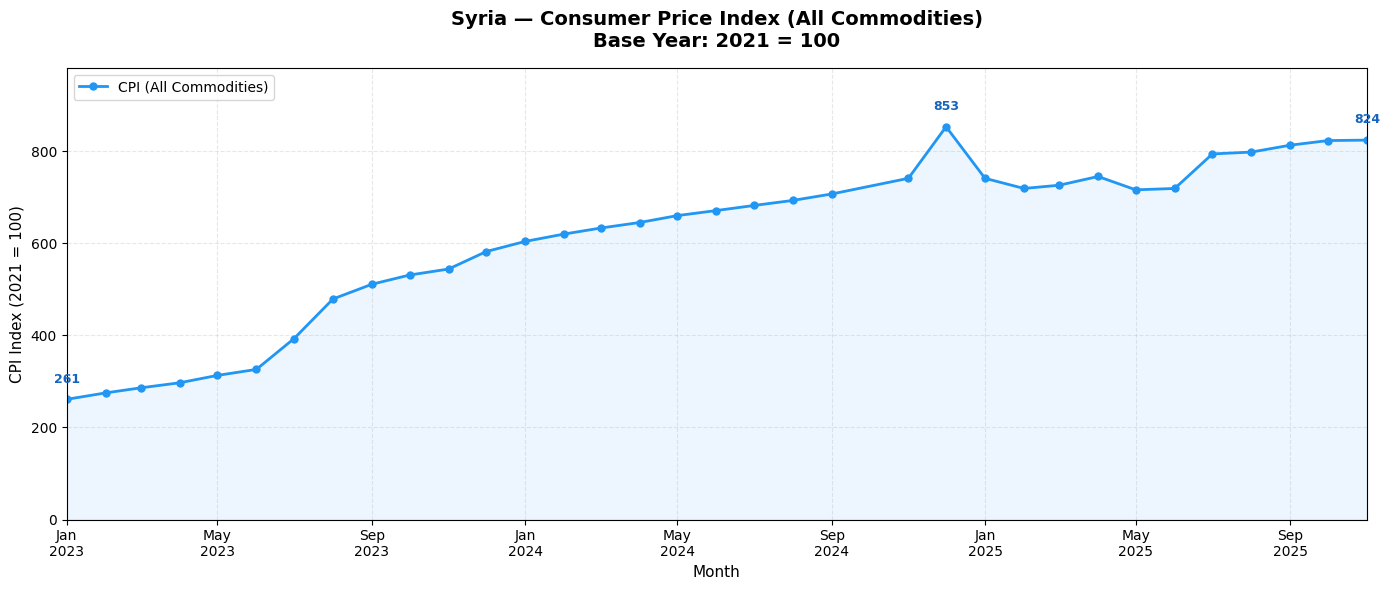


Data range: January 2023 — November 2025
CPI range: 261 — 853
Overall change: +215.7% from Jan 2023 to Nov 2025


In [ ]:
# %% [markdown]
# ## Syria CPI Trend (All Commodities)
# Extract Consumer Price Index from the Annexes table of each monthly bulletin
# and plot the trend over time. Base year: 2021 = 100.

# %%
import pdfplumber
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import os
import re
from datetime import datetime

# %%
DATA_DIR = "data/scpr_bulletins_cpi"

# Fixed mapping from column index → governorate name.
# All 32 PDFs have 26 columns with values at these exact positions.
GOVERNORATE_MAP = {
    1:  "Damascus",
    2:  "Rural Damascus",
    5:  "Homs",
    6:  "Hama",
    7:  "Tartous",
    8:  "Lattakia",
    9:  "Idleb",
    10: "Aleppo",
    11: "Ar-Raqqa",
    14: "Deir-ez-Zor",
    17: "Al-Hasakeh",
    20: "As-Sweida",
    23: "Dar'a",
    24: "Quneitra",
    25: "SYRIA",
}

# Normalise commodity label variants to a canonical name
COMMODITY_ALIASES = {
    "Clothing and Shoes": "Clothing and footwear",
}

# Month name → number, including known typos in SCPR bulletins
MONTH_NAME_TO_NUM = {
    "january": 1, "february": 2, "march": 3, "april": 4,
    "may": 5, "june": 6, "july": 7, "august": 8,
    "september": 9, "septemer": 9,  # typo in Issue 9-2024
    "october": 10, "november": 11, "december": 12,
}

def normalise_commodity(label):
    """Clean up multiline labels and apply alias mapping."""
    label = " ".join(label.split())  # collapse newlines/spaces
    return COMMODITY_ALIASES.get(label, label)

def extract_date_from_pdf(pdf_path):
    """
    Extract the bulletin month/year from the PDF title page.
    
    Looks for the pattern "Issue (N) – Month Year" in the first 5 pages.
    Falls back to the filename Issue-N-YYYY pattern if not found.
    
    Returns a datetime object for the 1st of the identified month.
    """
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages[:5]:
            text = page.extract_text() or ""
            # Pattern: Issue (N) – Month Year  (dash can be –, -, or —)
            m = re.search(
                r'Issue\s*\(?\s*\d+\s*\)?\s*[–\-—]\s*([A-Za-z]+)\s+(\d{4})',
                text
            )
            if m:
                month_name = m.group(1).lower()
                year = int(m.group(2))
                month_num = MONTH_NAME_TO_NUM.get(month_name)
                if month_num:
                    return datetime(year, month_num, 1)
    
    # Fallback: parse from filename
    fname = os.path.basename(pdf_path)
    m = re.search(r"Issue-(\d+)-(\d{4})", fname)
    if m:
        return datetime(int(m.group(2)), int(m.group(1)), 1)
    
    return None

def extract_all_cpi_from_pdf(pdf_path):
    """
    Extract CPI values for ALL commodity rows × ALL governorates from
    the Appendix table.
    
    Returns a dict: {commodity: {governorate: int, ...}, ...}
    or None on failure.
    """
    with pdfplumber.open(pdf_path) as pdf:
        for page in reversed(pdf.pages):
            text = page.extract_text() or ""
            if "all commodities" not in text.lower():
                continue
                
            tables = page.extract_tables()
            for table in tables:
                if not table or len(table) < 2:
                    continue
                    
                # Verify this is the right table (has SYRIA column)
                header = table[0]
                if not any(c and "SYRIA" in str(c).upper() for c in header):
                    continue
                
                # Skip percentage tables
                pct_check = False
                for row in table:
                    if row[0] and "all commodities" in str(row[0]).lower():
                        if any("%" in str(c or "") for c in row):
                            pct_check = True
                        break
                if pct_check:
                    continue  # try next table / page
                
                # Extract all data rows
                result = {}
                for row in table:
                    raw_label = str(row[0] or "").strip()
                    if not raw_label:
                        continue
                    label = normalise_commodity(raw_label)
                    
                    gov_values = {}
                    for idx, name in GOVERNORATE_MAP.items():
                        raw = str(row[idx] or "").replace(",", "").strip()
                        try:
                            gov_values[name] = int(raw)
                        except ValueError:
                            pass
                    
                    if gov_values:
                        result[label] = gov_values
                
                if "All commodities" in result and "SYRIA" in result["All commodities"]:
                    return result
    return None

def _parse_pct(val):
    """Parse SCPR percentage format: '%15.9' -> 15.9, '%1.0-' -> -1.0, '-\\n%12.9' -> -12.9"""
    if not val:
        return None
    clean = val.replace('%', '').replace('\n', '').strip()
    if clean.endswith('-'):
        clean = '-' + clean[:-1]
    try:
        return float(clean)
    except ValueError:
        return None

def extract_mom_table_from_pdf(pdf_path):
    """
    Extract the MoM % change table (Appendix 2) from a PDF, if present.
    
    Returns a dict: {commodity: {governorate: float(%), ...}, ...}
    or None if no such table exists.
    """
    with pdfplumber.open(pdf_path) as pdf:
        for page in reversed(pdf.pages):
            text = page.extract_text() or ""
            if "monthly inflation" not in text.lower() and "appendix (2)" not in text.lower():
                continue
            
            tables = page.extract_tables()
            for table in tables:
                if not table or len(table) < 2:
                    continue
                
                header = table[0]
                if not any(c and "SYRIA" in str(c).upper() for c in header):
                    continue
                
                # Verify this IS a percentage table
                has_pct = False
                for row in table:
                    if row[0] and "all commodities" in str(row[0]).lower():
                        if any("%" in str(c or "") for c in row):
                            has_pct = True
                        break
                if not has_pct:
                    continue
                
                result = {}
                for row in table:
                    raw_label = str(row[0] or "").strip()
                    if not raw_label:
                        continue
                    label = normalise_commodity(raw_label)
                    
                    gov_pcts = {}
                    for idx, name in GOVERNORATE_MAP.items():
                        p = _parse_pct(str(row[idx] or ""))
                        if p is not None:
                            gov_pcts[name] = p
                    
                    if gov_pcts:
                        result[label] = gov_pcts
                
                if "All commodities" in result:
                    return result
    return None

def back_calculate_previous_month(abs_cpi, mom_pct):
    """
    Given absolute CPI values and MoM % changes for a month,
    back-calculate the previous month's CPI values.
    
    nov_cpi = dec_cpi / (1 + pct/100)
    
    Returns: {commodity: {governorate: int, ...}, ...}
    """
    result = {}
    for commodity in abs_cpi:
        if commodity not in mom_pct:
            continue
        gov_vals = {}
        for gov in abs_cpi[commodity]:
            if gov in mom_pct[commodity]:
                dec_val = abs_cpi[commodity][gov]
                pct_val = mom_pct[commodity][gov]
                gov_vals[gov] = round(dec_val / (1 + pct_val / 100))
        if gov_vals:
            result[commodity] = gov_vals
    return result

# %%
# Process all monthly bulletins
pdf_files = sorted([
    f for f in os.listdir(DATA_DIR) 
    if f.lower().startswith("monthly") and f.endswith(".pdf")
])

records = []
errors = []
back_calc_candidates = []  # (pdf_path, bulletin_date, abs_cpi) for bulletins with MoM tables

for fname in pdf_files:
    print(f"Processing: {fname}...")
    pdf_path = os.path.join(DATA_DIR, fname)
    
    # Extract the actual date from the PDF title (not from filename)
    bulletin_date = extract_date_from_pdf(pdf_path)
    if bulletin_date is None:
        errors.append((fname, "Could not determine bulletin date"))
        continue
    
    # Check if filename issue number matches PDF title date
    fm = re.search(r"Issue-(\d+)-(\d{4})", fname)
    if fm:
        fn_month, fn_year = int(fm.group(1)), int(fm.group(2))
        if fn_month != bulletin_date.month or fn_year != bulletin_date.year:
            print(f"  ⚠ Date mismatch: filename says Issue {fn_month}-{fn_year}, "
                  f"PDF title says {bulletin_date.strftime('%B %Y')}")
    
    all_cpi = extract_all_cpi_from_pdf(pdf_path)
    if all_cpi is not None:
        records.append({
            "date": bulletin_date,
            "cpi": all_cpi["All commodities"]["SYRIA"],
            "governorates": all_cpi["All commodities"],
            "commodities": all_cpi,
            "file": fname,
        })
        # Check if this PDF also has a MoM % table (Appendix 2)
        mom_pct = extract_mom_table_from_pdf(pdf_path)
        if mom_pct:
            back_calc_candidates.append((pdf_path, bulletin_date, all_cpi, mom_pct))
    else:
        errors.append((fname, "Could not extract CPI values"))

# Sort chronologically
records.sort(key=lambda r: r["date"])

# %%
# Fill gaps: for each bulletin that has a MoM % table, check if the
# previous month is missing and back-calculate its CPI values.
existing_dates = {r["date"] for r in records}

for pdf_path, bulletin_date, abs_cpi, mom_pct in back_calc_candidates:
    # The previous month
    if bulletin_date.month == 1:
        prev_date = datetime(bulletin_date.year - 1, 12, 1)
    else:
        prev_date = datetime(bulletin_date.year, bulletin_date.month - 1, 1)
    
    if prev_date not in existing_dates:
        prev_cpi = back_calculate_previous_month(abs_cpi, mom_pct)
        if "All commodities" in prev_cpi and "SYRIA" in prev_cpi["All commodities"]:
            records.append({
                "date": prev_date,
                "cpi": prev_cpi["All commodities"]["SYRIA"],
                "governorates": prev_cpi["All commodities"],
                "commodities": prev_cpi,
                "file": f"[back-calculated from {os.path.basename(pdf_path)}]",
            })
            existing_dates.add(prev_date)
            print(f"✓ Back-calculated {prev_date.strftime('%B %Y')} CPI from "
                  f"{os.path.basename(pdf_path)} MoM table")
        else:
            print(f"⚠ Could not back-calculate {prev_date.strftime('%B %Y')}")

# Re-sort after adding back-calculated records
records.sort(key=lambda r: r["date"])

# Collect all commodity names
all_commodities = sorted({c for r in records for c in r["commodities"]})

print(f"\nExtracted CPI from {len(records)} months ({len(pdf_files)} bulletins)")
print(f"Commodity categories: {len(all_commodities)}")
for c in all_commodities:
    print(f"  - {c}")

if errors:
    print(f"\nErrors ({len(errors)}):")
    for fname, msg in errors:
        print(f"  {fname}: {msg}")

# Show latest bulletin summary
# print(f"\nLatest bulletin ({records[-1]['date'].strftime('%b %Y')}) — CPI by governorate (All commodities):")
# for gov, val in sorted(records[-1]["governorates"].items()):
#     print(f"  {gov:20s}: {val}")

# %%
# Plot CPI trend (SYRIA aggregate)
dates = [r["date"] for r in records]
cpis = [r["cpi"] for r in records]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(dates, cpis, "o-", color="#2196F3", linewidth=2, markersize=5, label="CPI (All Commodities)")
ax.fill_between(dates, cpis, alpha=0.08, color="#2196F3")

# Annotate min, max, and last value
for idx in [0, cpis.index(max(cpis)), -1]:
    ax.annotate(
        f"{cpis[idx]}", 
        (dates[idx], cpis[idx]),
        textcoords="offset points", xytext=(0, 12),
        ha="center", fontsize=9, fontweight="bold", color="#1565C0"
    )

ax.set_title("Syria — Consumer Price Index (All Commodities)\nBase Year: 2021 = 100", 
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("CPI Index (2021 = 100)", fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--")
ax.legend(loc="upper left", fontsize=10)

# Format x-axis
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: plt.matplotlib.dates.num2date(x).strftime("%b\n%Y")))
fig.autofmt_xdate(rotation=0, ha="center")

ax.set_xlim(dates[0], dates[-1])
ax.set_ylim(0, max(cpis) * 1.15)

plt.tight_layout()
plt.show()

print(f"\nData range: {dates[0].strftime('%B %Y')} — {dates[-1].strftime('%B %Y')}")
print(f"CPI range: {min(cpis)} — {max(cpis)}")
print(f"Overall change: +{((cpis[-1] / cpis[0]) - 1) * 100:.1f}% from {dates[0].strftime('%b %Y')} to {dates[-1].strftime('%b %Y')}")

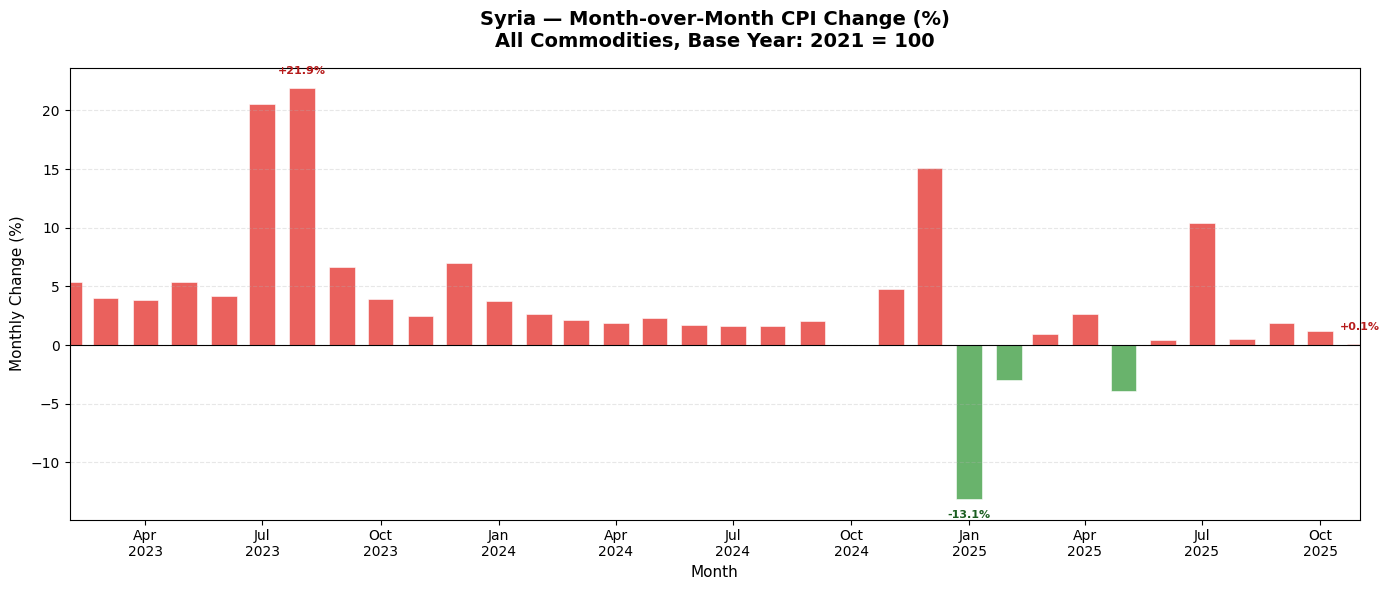


Monthly CPI changes (Feb 2023 — Nov 2025):
  Average monthly change:  +3.73%
  Median monthly change:   +2.45%
  Months with inflation:   30
  Months with deflation:   3
  Max increase: +21.9% (Aug 2023)
  Max decrease: -13.1% (Jan 2025)


In [44]:
# %% [markdown]
# ## Month-over-Month CPI Change (%)
# Compute and plot the percentage change in CPI between consecutive months.

# %%
import numpy as np

# Compute month-over-month percentage changes
mom_dates = [r["date"] for r in records[1:]]
mom_changes = [
    ((records[i]["cpi"] - records[i-1]["cpi"]) / records[i-1]["cpi"]) * 100
    for i in range(1, len(records))
]

fig, ax = plt.subplots(figsize=(14, 6))

# Color bars by sign: green for deflation, red for inflation
colors = ["#E53935" if c > 0 else "#43A047" for c in mom_changes]
bars = ax.bar(mom_dates, mom_changes, width=20, color=colors, alpha=0.8, edgecolor="white", linewidth=0.5)

# Add a zero line
ax.axhline(y=0, color="black", linewidth=0.8)

# Annotate notable values (max increase, max decrease, last)
max_idx = int(np.argmax(mom_changes))
min_idx = int(np.argmin(mom_changes))
for idx in set([max_idx, min_idx, len(mom_changes)-1]):
    ax.annotate(
        f"{mom_changes[idx]:+.1f}%",
        (mom_dates[idx], mom_changes[idx]),
        textcoords="offset points",
        xytext=(0, 10 if mom_changes[idx] >= 0 else -14),
        ha="center", fontsize=8, fontweight="bold",
        color="#B71C1C" if mom_changes[idx] > 0 else "#1B5E20"
    )

ax.set_title("Syria — Month-over-Month CPI Change (%)\nAll Commodities, Base Year: 2021 = 100",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xlabel("Month", fontsize=11)
ax.set_ylabel("Monthly Change (%)", fontsize=11)
ax.grid(True, alpha=0.3, linestyle="--", axis="y")

# Format x-axis
ax.xaxis.set_major_formatter(mticker.FuncFormatter(
    lambda x, _: plt.matplotlib.dates.num2date(x).strftime("%b\n%Y")
))
fig.autofmt_xdate(rotation=0, ha="center")

ax.set_xlim(mom_dates[0], mom_dates[-1])

plt.tight_layout()
plt.show()

# Summary stats
avg_change = np.mean(mom_changes)
median_change = np.median(mom_changes)
positive_months = sum(1 for c in mom_changes if c > 0)
negative_months = sum(1 for c in mom_changes if c < 0)

print(f"\nMonthly CPI changes ({mom_dates[0].strftime('%b %Y')} — {mom_dates[-1].strftime('%b %Y')}):")
print(f"  Average monthly change:  {avg_change:+.2f}%")
print(f"  Median monthly change:   {median_change:+.2f}%")
print(f"  Months with inflation:   {positive_months}")
print(f"  Months with deflation:   {negative_months}")
print(f"  Max increase: {max(mom_changes):+.1f}% ({mom_dates[max_idx].strftime('%b %Y')})")
print(f"  Max decrease: {min(mom_changes):+.1f}% ({mom_dates[min_idx].strftime('%b %Y')})")

# Wage Extraction

In [47]:
# %% [markdown]
# ## Average Monthly Wages by Control Area
# Extract wage data from the "Average monthly wages in Syria" table
# found in each monthly bulletin. Values are in SYP.
#
# 6 wage categories × 4 control areas (SYP-Governed, TL-Governed, AA, Whole of Syria)

# %%
# Wage label normalization → canonical category names
WAGE_ALIASES = {
    "professor": "Public: Professor",
    "university professor": "Public: Professor",
    "university-educated": None,  # ambiguous → resolved by sector context
    "university educated": None,
    "university grad": None,
    "4th band": "Public: 4th Band",
    "4th grade": "Public: 4th Band",
    "basic education": "Public: 4th Band",
    "preparatory": "Public: 4th Band",
    "company director": "Private: Company Director",
    "company manager": "Private: Company Director",
    "shop worker": "Private: Shop Worker",
}


def _detect_area_cols(table):
    """Detect which column indices map to which control areas from header rows."""
    area_cols = {}
    header_text = {}
    for row in table[:min(5, len(table))]:
        for col_idx, cell in enumerate(row):
            txt = str(cell or '').strip().lower()
            if txt:
                header_text.setdefault(col_idx, '')
                header_text[col_idx] += ' ' + txt

    for col_idx, txt in header_text.items():
        txt = txt.strip()
        if any(k in txt for k in ['gos', 'syp', 'caretaker', 'former']):
            area_cols[col_idx] = 'SYP-Governed'
        elif any(k in txt for k in ['sig', 'ssg', 'tl-', 'tl area', 'tl governe']):
            area_cols[col_idx] = 'TL-Governed'
        elif 'aa' in txt.split()[0] if txt.split() else False:
            area_cols[col_idx] = 'AA'
        elif 'whole of' in txt or txt == 'syria':
            area_cols[col_idx] = 'Whole of Syria'

    return area_cols if len(area_cols) >= 3 else None


def _find_value_cols(table, area_cols):
    """For each detected area header column, find candidate value columns."""
    seen_areas = set()
    value_cols = {}
    for col_idx, area_name in sorted(area_cols.items()):
        if area_name in seen_areas:
            continue
        seen_areas.add(area_name)
        candidates = []
        for try_col in [col_idx, col_idx + 1, col_idx - 1, col_idx + 2]:
            if try_col < 0:
                continue
            count = sum(
                1 for row in table[2:]
                if try_col < len(row) and
                str(row[try_col] or '').replace(',', '').replace(' ', '').strip().isdigit()
            )
            if count > 0:
                candidates.append((count, try_col))
        candidates.sort(reverse=True)
        if candidates:
            value_cols[area_name] = [c[1] for c in candidates]
    return value_cols


def _classify_wage(label, sector):
    """Map a row label + current sector to a canonical wage category."""
    label_lower = label.lower()
    for key, val in WAGE_ALIASES.items():
        if key in label_lower:
            if val is not None:
                return val
            if sector == 'public':
                return "Public: University Grad"
            elif sector == 'civil':
                return "Civil: University Grad"
            break
    return None


def extract_wages_from_pdf(pdf_path):
    """
    Extract average monthly wages from the bulletin's wage table.

    Returns: {wage_category: {area: int, ...}, ...} or None
    """
    with pdfplumber.open(pdf_path) as pdf:
        for page in pdf.pages:
            text = page.extract_text() or ''
            if 'average monthly wage' not in text.lower():
                continue

            tables = page.extract_tables()
            for table in tables:
                if not table or len(table) < 5:
                    continue
                flat = ' '.join(str(c or '') for row in table for c in row).lower()
                if 'public sector' not in flat:
                    continue

                area_cols = _detect_area_cols(table)
                if not area_cols:
                    continue
                value_cols = _find_value_cols(table, area_cols)
                if len(value_cols) < 3:
                    continue

                result = {}
                current_sector = None

                for i in range(len(table)):
                    row = table[i]
                    label = str(row[0] or '').strip() + ' ' + str(row[1] or '').strip()
                    label = ' '.join(label.split()).strip()

                    # Merge split labels (e.g. "Professor)" on next row)
                    if i + 1 < len(table):
                        nxt = ' '.join((str(table[i+1][0] or '') + ' ' + str(table[i+1][1] or '')).split()).strip()
                        if nxt and (nxt.startswith('(') or nxt.endswith(')')):
                            label = label + ' ' + nxt

                    label_lower = label.lower()

                    if 'public sector' in label_lower:
                        current_sector = 'public'; continue
                    elif 'private sector' in label_lower:
                        current_sector = 'private'; continue
                    elif 'civil' in label_lower and ('sector' in label_lower or 'society' in label_lower):
                        current_sector = 'civil'; continue

                    area_vals = {}
                    for area_name, col_candidates in value_cols.items():
                        for try_col in col_candidates:
                            if try_col < len(row):
                                raw = str(row[try_col] or '').replace(',', '').replace(' ', '').strip()
                                try:
                                    area_vals[area_name] = int(raw)
                                    break
                                except ValueError:
                                    pass

                    if not area_vals:
                        continue
                    wage_cat = _classify_wage(label, current_sector)
                    if wage_cat:
                        result[wage_cat] = area_vals

                if len(result) >= 4:
                    return result
    return None


# %%
# Process all monthly bulletins for wage data
wage_records = []
wage_errors = []

for fname in pdf_files:
    pdf_path = os.path.join(DATA_DIR, fname)
    bulletin_date = extract_date_from_pdf(pdf_path)
    if bulletin_date is None:
        continue

    wages = extract_wages_from_pdf(pdf_path)
    if wages is not None:
        wage_records.append({
            "date": bulletin_date,
            "wages": wages,
            "file": fname,
        })
    else:
        wage_errors.append(fname)

wage_records.sort(key=lambda r: r["date"])

# Collect all wage categories and control areas
all_wage_cats = sorted({c for r in wage_records for c in r["wages"]})
all_areas = sorted({a for r in wage_records for v in r["wages"].values() for a in v})

print(f"Extracted wages from {len(wage_records)}/{len(pdf_files)} bulletins")
print(f"Wage categories ({len(all_wage_cats)}):")
for c in all_wage_cats:
    print(f"  - {c}")
print(f"Control areas ({len(all_areas)}):")
for a in all_areas:
    print(f"  - {a}")

if wage_errors:
    print(f"\nSkipped ({len(wage_errors)} bulletins — no wage table found):")
    for f in wage_errors:
        print(f"  {f}")

# Show latest wages
latest_w = wage_records[-1]
print(f"\nLatest wages ({latest_w['date'].strftime('%b %Y')}) — Whole of Syria:")
for cat in all_wage_cats:
    val = latest_w["wages"].get(cat, {}).get("Whole of Syria", "N/A")
    if isinstance(val, int):
        print(f"  {cat:30s}: SYP {val:>12,}")
    else:
        print(f"  {cat:30s}: {val}")

Extracted wages from 32/33 bulletins
Wage categories (6):
  - Civil: University Grad
  - Private: Company Director
  - Private: Shop Worker
  - Public: 4th Band
  - Public: Professor
  - Public: University Grad
Control areas (4):
  - AA
  - SYP-Governed
  - TL-Governed
  - Whole of Syria

Skipped (1 bulletins — no wage table found):
  Monthly-Bulletin-Issue-3-2025-En.pdf

Latest wages (Nov 2025) — Whole of Syria:
  Civil: University Grad        : SYP    2,967,658
  Private: Company Director     : SYP    4,245,223
  Private: Shop Worker          : SYP    1,303,698
  Public: 4th Band              : SYP      965,208
  Public: Professor             : SYP    3,384,569
  Public: University Grad       : SYP    1,151,013


In [48]:
# %% [markdown]
# ## Export data to JSON & Generate Dashboard
# Export CPI records (with per-governorate and per-commodity breakdown)
# and wage records to a JSON file that the dashboard HTML loads at runtime.

# %%
import json

# Collect all governorate and commodity names
all_govs = sorted({g for r in records for g in r["governorates"] if g != "SYRIA"})
all_commodities_export = sorted({c for r in records for c in r["commodities"] if c != "All commodities"})

gov_list = ["SYRIA"] + all_govs
commodity_list = ["All commodities"] + all_commodities_export

export_data = {
    "base_year": 2021,
    "source": "Syrian Center for Policy Research (SCPR)",
    "source_url": "https://scpr-syria.org/publications/bulletins/",
    "governorates": gov_list,
    "commodities": commodity_list,
    "records": [
        {
            "date": r["date"].strftime("%Y-%m-%d"),
            **{
                commodity: {
                    gov: r["commodities"].get(commodity, {}).get(gov)
                    for gov in gov_list
                }
                for commodity in commodity_list
            }
        }
        for r in records
    ],
    # --- Wage data ---
    "wage_categories": sorted(all_wage_cats),
    "control_areas": sorted(all_areas),
    "wage_records": [
        {
            "date": wr["date"].strftime("%Y-%m-%d"),
            **{
                cat: wr["wages"].get(cat, {})
                for cat in all_wage_cats
            }
        }
        for wr in wage_records
    ],
}

json_path = "data/cpi_data.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(export_data, f, indent=2)

print(f"Exported {len(records)} CPI records × {len(gov_list)} regions × {len(commodity_list)} commodities")
print(f"Exported {len(wage_records)} wage records × {len(all_wage_cats)} categories × {len(all_areas)} areas")
print(f"Output: {json_path}")
print(f"CPI date range: {records[0]['date'].strftime('%b %Y')} — {records[-1]['date'].strftime('%b %Y')}")
print(f"Wage date range: {wage_records[0]['date'].strftime('%b %Y')} — {wage_records[-1]['date'].strftime('%b %Y')}")
print(f"\nRe-run the notebook after downloading new bulletins to update the data.")

Exported 34 CPI records × 15 regions × 12 commodities
Exported 32 wage records × 6 categories × 4 areas
Output: data/cpi_data.json
CPI date range: Jan 2023 — Nov 2025
Wage date range: Jan 2023 — Nov 2025

Re-run the notebook after downloading new bulletins to update the data.


In [46]:
!cd ~/Documents/personal_projects/syria_in_numbers && python -m http.server 8000

Serving HTTP on :: port 8000 (http://[::]:8000/) ...
::1 - - [26/Feb/2026 16:05:40] "GET / HTTP/1.1" 304 -
::1 - - [26/Feb/2026 16:05:40] "GET /data/cpi_data.json HTTP/1.1" 200 -
^C
